# Этот ноутбук содержит в себе визуализации кластеров из объединённого датафрейма АПК + химия

In [133]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.vis import plot_tsne_similarity, plot_tsne_similarity_plotly
from utils.misc import save_dict_as_json
from sklearn.preprocessing import MinMaxScaler, StandardScaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
df = pd.read_csv(
    "/home/danilach/mipt-stats/SberTs/Data/comb_df_v1.csv", index_col=0
)
df.index = pd.to_datetime(df.index)

# T-SNE

Посмотрим на кластеризацию методом t-sne рядов, и на то каким кластерам принадлежат показатели. Посмотри на ра различные метрики расстояния

## 

Метрики расстояния

In [135]:
pdist_list = [
    "nan_euclidean",
    "chebyshev",
    "l2",
    "cityblock",
    "l1",
    "braycurtis",
    "manhattan",
    "sqeuclidean",
    "correlation",
    "cosine",
    "canberra",
    "minkowski",
]

Словари групп
- `apk_chem_groups` - группы по датасетам (АПК и химия)
- `Dastan groups` - группы Дастана и добавленная химия разбитая по визуальному приницпу

## dastan_groups

In [136]:
import json

# Path to your JSON file
path = "/home/danilach/mipt-stats/SberTs/clusters/v1.json"

# Read dictionary from JSON
with open(path, "r") as json_file:
    loaded_dict = json.load(json_file)

print(loaded_dict)


{'Кукуруза': 'Grains & Seeds', 'Пшеница 1-го класса': 'Grains & Seeds', 'Пшеница 3-го класса': 'Grains & Seeds', 'Пшеница 4-го класса': 'Grains & Seeds', 'Пшеница 5-го класса': 'Grains & Seeds', 'Пшеница 12,5% FOB Ново, руб/т': 'Grains & Seeds', 'Подсолнечник': 'Grains & Seeds', 'Соя': 'Grains & Seeds', 'Рапс, руб./т': 'Grains & Seeds', 'Подсолнечное масло наливом (мировые цены)': 'Oils & Meals', 'Бутилированное подсолнечное масло (рафинированное)': 'Oils & Meals', 'Подсолнечное масло (наливом) не бутилированное, нерафинированное ': 'Oils & Meals', 'Подсолнечный шрот ': 'Oils & Meals', 'Соевое масло': 'Oils & Meals', 'Соевый шрот': 'Oils & Meals', 'Рапсовое масло EU, руб/т': 'Oils & Meals', 'Кокосовое масло (USD) ': 'Oils & Meals', 'Кокосовое масло ': 'Oils & Meals', 'Пальмовое масло (USD)': 'Oils & Meals', 'Пальмовое масло ': 'Oils & Meals', 'Молоко сырое': 'Livestock & Meat', 'Мясо птицы бройлеров в живом весе ': 'Livestock & Meat', 'Мясо крупного рогатого скота в живом весе ': 'Live

In [137]:
dastan_groups = loaded_dict

In [138]:
dastan_groups

{'Кукуруза': 'Grains & Seeds',
 'Пшеница 1-го класса': 'Grains & Seeds',
 'Пшеница 3-го класса': 'Grains & Seeds',
 'Пшеница 4-го класса': 'Grains & Seeds',
 'Пшеница 5-го класса': 'Grains & Seeds',
 'Пшеница 12,5% FOB Ново, руб/т': 'Grains & Seeds',
 'Подсолнечник': 'Grains & Seeds',
 'Соя': 'Grains & Seeds',
 'Рапс, руб./т': 'Grains & Seeds',
 'Подсолнечное масло наливом (мировые цены)': 'Oils & Meals',
 'Бутилированное подсолнечное масло (рафинированное)': 'Oils & Meals',
 'Подсолнечное масло (наливом) не бутилированное, нерафинированное ': 'Oils & Meals',
 'Подсолнечный шрот ': 'Oils & Meals',
 'Соевое масло': 'Oils & Meals',
 'Соевый шрот': 'Oils & Meals',
 'Рапсовое масло EU, руб/т': 'Oils & Meals',
 'Кокосовое масло (USD) ': 'Oils & Meals',
 'Кокосовое масло ': 'Oils & Meals',
 'Пальмовое масло (USD)': 'Oils & Meals',
 'Пальмовое масло ': 'Oils & Meals',
 'Молоко сырое': 'Livestock & Meat',
 'Мясо птицы бройлеров в живом весе ': 'Livestock & Meat',
 'Мясо крупного рогатого скота

In [139]:
colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "violet",
    "olive",
    "cyan",
    "black"
]
unique_values = list(set(dastan_groups.values()))
value_to_color = {value: colors[i] for i, value in enumerate(unique_values)}
color_dict = {key: value_to_color[value] for key, value in dastan_groups.items()}

In [144]:
for metric in pdist_list:
    plot_tsne_similarity_plotly(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=MinMaxScaler,
        group_dict=dastan_groups,
        title=metric,
        legend=False,
    )

visual_chem

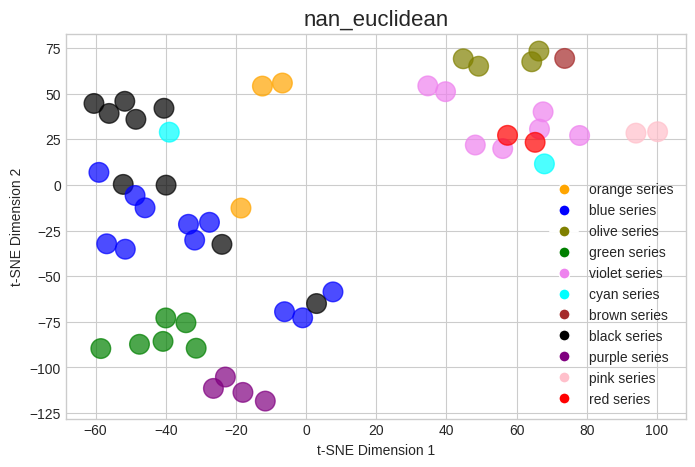

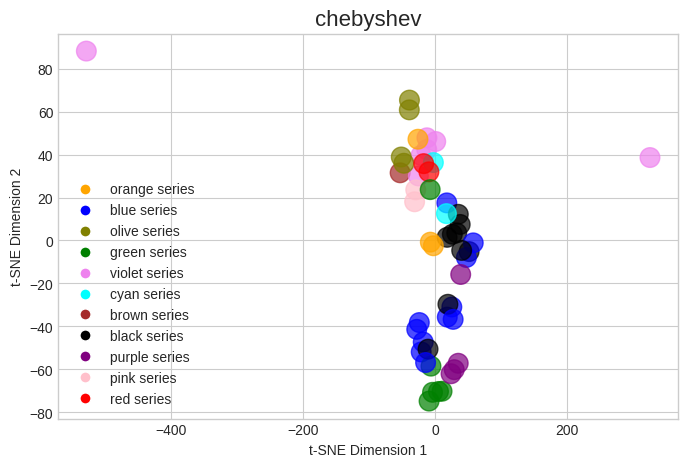

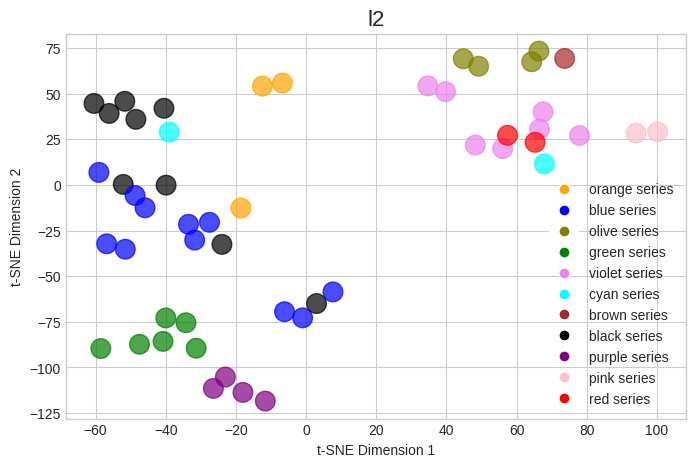

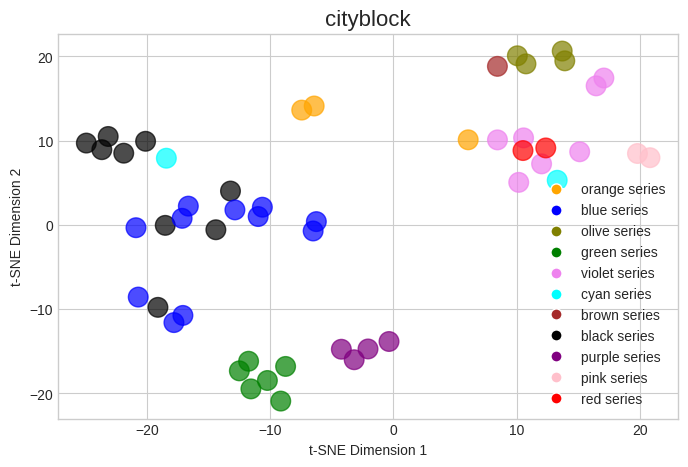

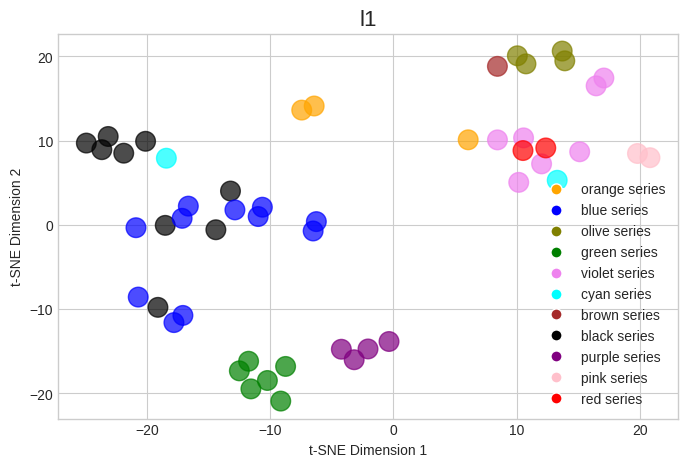

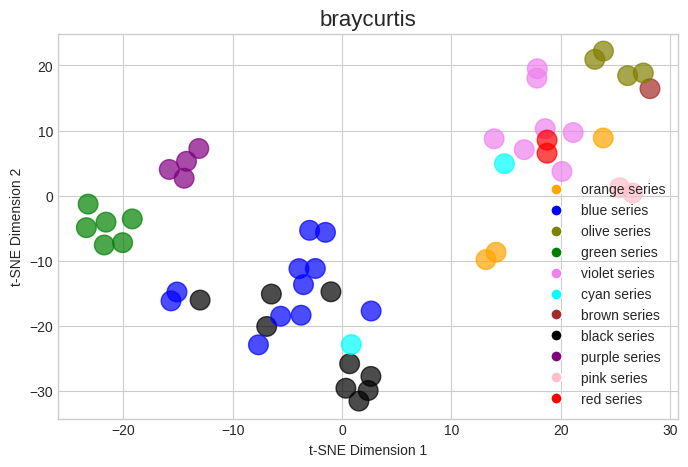

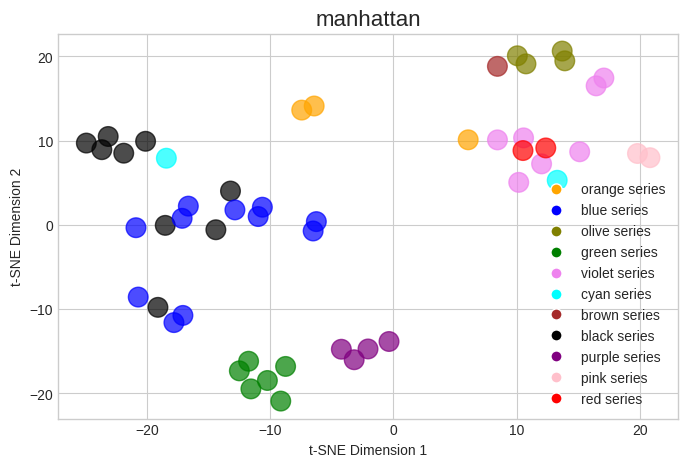

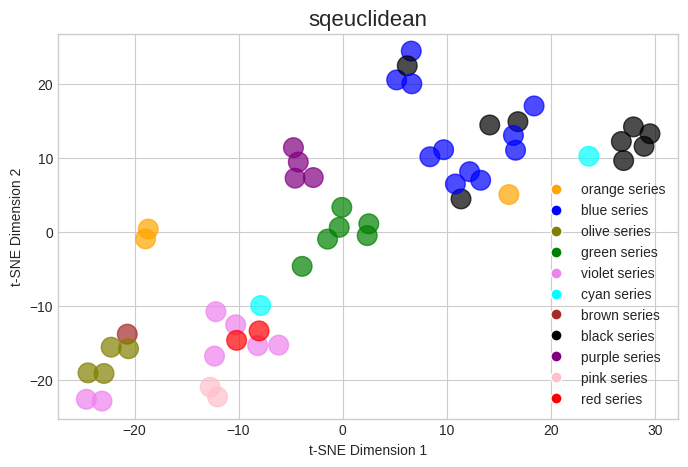

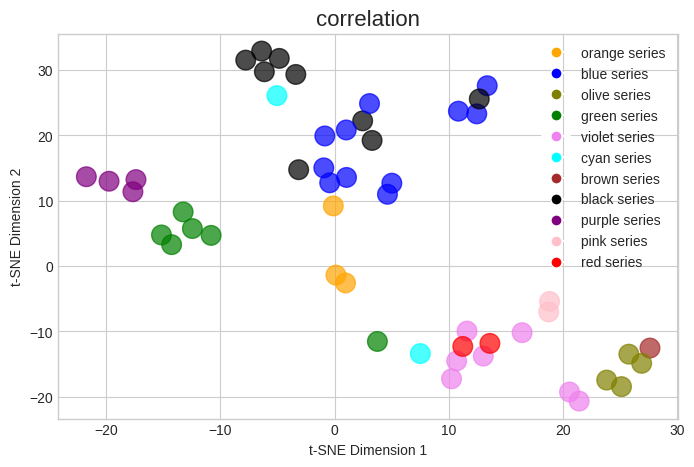

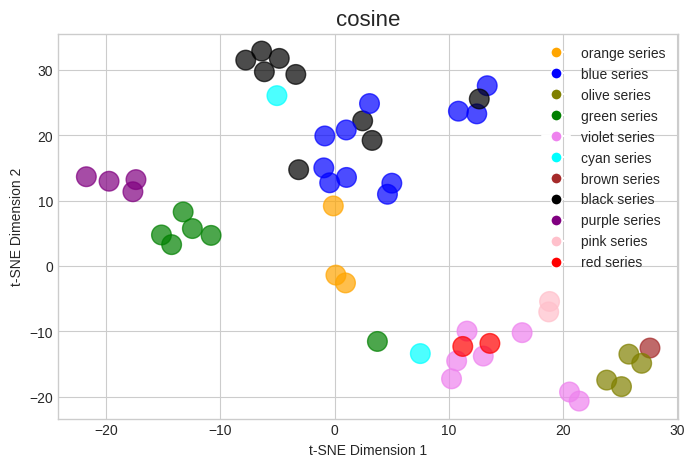

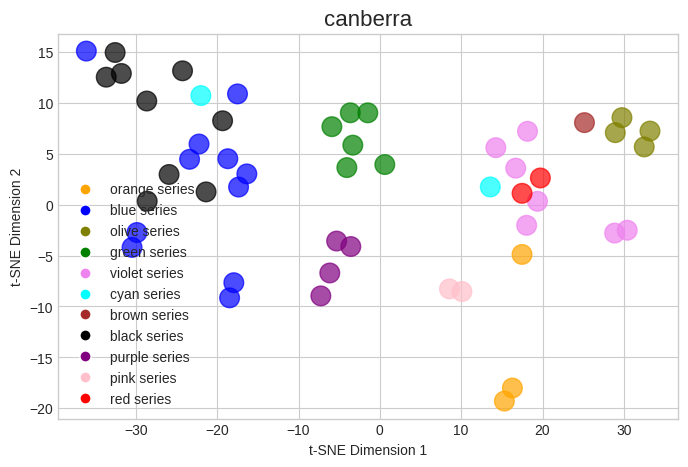

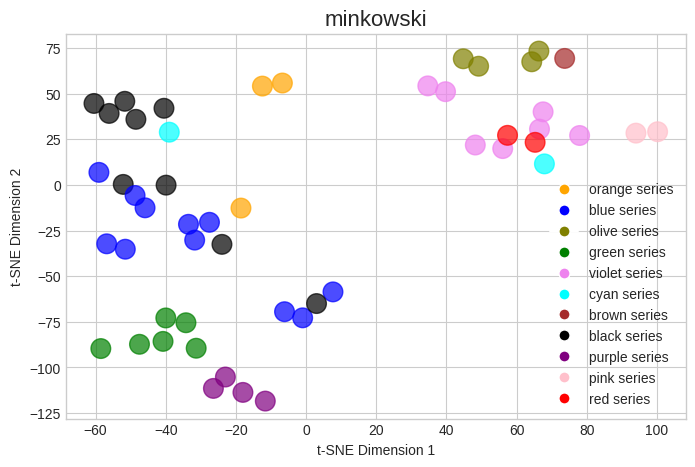

In [145]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=StandardScaler,
        annotate=False,
        title=metric,
    )